# Drought Monitoring and Early Warning

This lesson uses the `drought` module to describe historical drought
conditions and forecast the next six months for a northern Kenya AOI.

**Learning objectives**

- explain the Composite Drought Index (CDI);
- select a suitable climatological baseline;
- run the asynchronous analysis API;
- interpret severity, sub-indices, and forecast uncertainty;
- distinguish temporal summaries from spatial outputs.


## 1. Prepare the notebook session

This cell imports the tools used throughout the lesson and loads configuration
from a local `.env` file. The Earth Engine project identifier is configuration,
not analysis data, so it is kept outside the notebook.

Before running the notebook:

1. copy `.env.example` to `.env`;
2. replace the placeholder with your Google Earth Engine project ID;
3. run `earthengine authenticate` once in a terminal;
4. select the **Climate Change Workflows** kernel.

The `%matplotlib inline` backend renders figures directly below each plotting cell.


In [4]:
from dataclasses import asdict
from pathlib import Path
import os

from IPython import get_ipython

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from climate_change import USE_CASE_REGISTRY, run_analysis

WORKSPACE = Path.cwd()
if not (WORKSPACE / ".venv").exists() and (WORKSPACE.parent / ".venv").exists():
    WORKSPACE = WORKSPACE.parent

load_dotenv(WORKSPACE / ".env")
GEE_PROJECT = os.environ.get("GEE_PROJECT", "").strip()
if not GEE_PROJECT:
    raise RuntimeError("Create .env from .env.example and set GEE_PROJECT.")

OUTPUT_DIR = WORKSPACE / "outputs"
REPORT_DIR = WORKSPACE / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

print("Workspace:", WORKSPACE)
print("Earth Engine project configured:", bool(GEE_PROJECT))

Workspace: /home/odero-george/workspace/climate-change
Earth Engine project configured: True


## 2. Inspect the package registry

The registry is the package's catalogue of supported analyses. It documents the
recommended date range, dependent variable, input variables, and selectable models.
Inspecting it before running an analysis helps us choose scientifically sensible
parameters instead of treating the model as a black box.


In [5]:
info = USE_CASE_REGISTRY["drought"]
print(info.name)
print("\nPurpose:", info.description)
print("\nPredicted variable:", info.dependent_variable)
print("\nDate guidance:", info.date_guidance)
print("\nAvailable models:")
for option in info.model_options:
    marker = " (recommended)" if option.recommended else ""
    print(f"  - {option.id}: {option.label}{marker} — {option.note}")


Drought Monitoring & Early Warning

Purpose: This tool measures current drought conditions and forecasts whether drought is likely to worsen using a Composite Drought Index (CDI) that combines rainfall deficits, vegetation stress, and temperature extremes. It shows drought severity by area and how conditions have changed over time.

Predicted variable: Composite Drought Index (CDI) class (Extreme / Severe / Moderate / Mild / Near Normal / Wet)

Date guidance: Select 10–30 years for climatological baseline. Minimum 5 years for trend detection.

Available models:
  - lstm: LSTM Forecast (recommended) — MC Dropout uncertainty · 6-month horizon
  - drought_monitoring: drought-monitoring statistical — Package built-in · faster


## 3. Mathematical/Scientific model

The Composite Drought Index combines precipitation, temperature, and
Vegetation information:

$$
\mathrm{CDI}_t =
0.50\,\mathrm{PDI}_t +
0.25\,\mathrm{TDI}_t +
0.25\,\mathrm{VDI}_t
$$

where:

- $\mathrm{PDI}$ measures precipitation deficit;
- $\mathrm{TDI}$ measures thermal stress;
- $\mathrm{VDI}$ measures vegetation stress.

Lower values represent drier conditions. A value close to $1$ is near
normal, while values below $0.5$ indicate extreme drought.

The LSTM forecast estimates a vector of future CDI values:

$$
\hat{\mathbf{y}}_{t+1:t+H}
= f_{\theta}(\mathbf{x}_{t-L+1:t})
$$

where $L$ is the input sequence length and $H=6$ months is the forecast
horizon. Monte Carlo dropout repeats inference to estimate uncertainty.


## 4. Define the AOI and analysis configuration

The AOI is an approximate rectangle around Marsabit County, Kenya.
Drought analysis benefits from a long baseline, so this example uses
2005–2024. Replace the polygon with an authoritative boundary in applied work.


In [6]:
aoi = {
    "type": "Polygon",
    "coordinates": [[
        [36.00, 1.00], [38.20, 1.00], [38.20, 3.70],
        [36.00, 3.70], [36.00, 1.00],
    ]],
}

analysis_args = {
    "module": "drought",
    "aoi_geojson": aoi,
    "start_date": "2005-01-01",
    "end_date": "2024-12-31",
    "country": "Kenya",
    "gee_project": GEE_PROJECT,
    "extra_params": {
        "model_type": "lstm",
        "output_dir": str(OUTPUT_DIR),
    },
}
analysis_args

{'module': 'drought',
 'aoi_geojson': {'type': 'Polygon',
  'coordinates': [[[36.0, 1.0],
    [38.2, 1.0],
    [38.2, 3.7],
    [36.0, 3.7],
    [36.0, 1.0]]]},
 'start_date': '2005-01-01',
 'end_date': '2024-12-31',
 'country': 'Kenya',
 'gee_project': 'parallelprocessing-433914',
 'extra_params': {'model_type': 'lstm',
  'output_dir': '/home/odero-george/workspace/climate-change/outputs'}}

## 5. Run the analysis

`run_analysis` is asynchronous because data retrieval and model execution may be
long-running operations. Jupyter supports top-level `await`, so no explicit event
loop is required here.

The first run may take several minutes. Runtime depends on AOI size, temporal
coverage, Earth Engine quota, sampling resolution, and model choice.


In [7]:
output = await run_analysis(**analysis_args)
print("Analysis complete:", output.module)

2026-07-03 16:40:54,067 - distributed.http.proxy - INFO - To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
2026-07-03 16:40:54,096 - distributed.scheduler - INFO - State start
2026-07-03 16:40:54,098 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-rbw6irxg', purging
2026-07-03 16:40:54,099 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-zx2zdsk1', purging
2026-07-03 16:40:54,099 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-feeieamu', purging
2026-07-03 16:40:54,100 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-off1tpg4', purging
2026-07-03 16:40:54,101 - distributed.diskutils - INFO - Found stale lock file and directory '/tmp/dask-scratch-space/scheduler-ykifu4b6', purging
2026-07-03 16:4

✓ COG written → /home/odero-george/workspace/climate-change/outputs/drought_2005_2024_PDI.tif  (19 bands, 27×22 px, 0.13 MB)
✓ COG written → /home/odero-george/workspace/climate-change/outputs/drought_2005_2024_TDI.tif  (19 bands, 27×22 px, 0.13 MB)
✓ COG written → /home/odero-george/workspace/climate-change/outputs/drought_2005_2024_VDI.tif  (19 bands, 27×22 px, 0.13 MB)
✓ COG written → /home/odero-george/workspace/climate-change/outputs/drought_2005_2024_CDI.tif  (19 bands, 27×22 px, 0.13 MB)
Analysis complete: drought


## 6. Inspect the common output contract

Every use case returns an `AnalysisOutput` object with the same top-level fields:

- `stats`: summary indicators suitable for dashboards and reports;
- `charts`: structured time-series and distribution data;
- `geojson`: spatial features for a web map or GIS;
- `raster_path`: generated Cloud-Optimized GeoTIFF path(s), when available;
- `shap`: feature-importance information for supported models;
- `metadata`: model, period, country, and optional report information.

The internal keys of `stats` and `charts` remain specific to each scientific domain.


In [8]:
print("Module:", output.module)
print("Raster output:", output.raster_path)
print("GeoJSON feature count:", len(output.geojson.get("features", [])))
print("Chart payloads:", sorted(output.charts))
print("Metadata:", output.metadata)

pd.Series(output.stats, name="value").to_frame()


Module: drought
Raster output: {'PDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_PDI.tif', 'TDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_TDI.tif', 'VDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_VDI.tif', 'CDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_CDI.tif'}
GeoJSON feature count: 72
Chart payloads: ['anomaly', 'forecast', 'seasonal', 'severity_distribution', 'temporal_severity_distribution', 'timeseries', 'training', 'typology', 'uncertainty']
Metadata: {'model': 'drought-monitoring CDI + lstm', 'package_version': '0.1.7', 'country': 'Kenya', 'start_date': '2005-01-01', 'end_date': '2024-12-31', 'raster': {'PDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_PDI.tif', 'TDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_TDI.tif', 'VDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_VDI.ti

,value
model_type,lstm
analysis_year,2023
mean_cdi,0.7675
latest_mean_cdi,0.7909
aoi_valid_pixel_count,560
extreme_pct,0.0
severe_pct,7.7
moderate_pct,43.0
mild_pct,33.8
near_normal_pct,15.2


## 7. Visualize drought history and forecast

The first panel separates the component indices so we can see whether rainfall,
heat, or vegetation drives the CDI. The second panel presents CDI itself.

Forecast uncertainty is summarized using an interval:

$$
\left[\hat{\mu}_h - 1.96\hat{\sigma}_h,\;
\hat{\mu}_h + 1.96\hat{\sigma}_h\right]
$$

where $\hat{\mu}_h$ and $\hat{\sigma}_h$ are the Monte Carlo mean and
standard deviation for forecast month $h$.


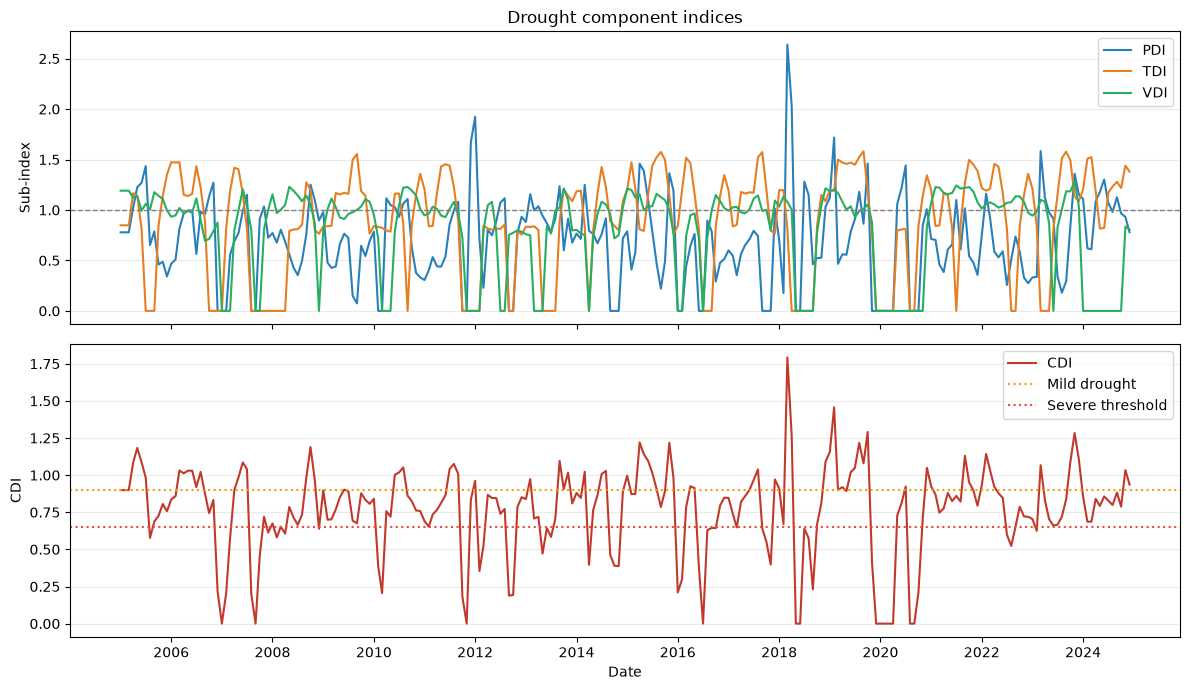

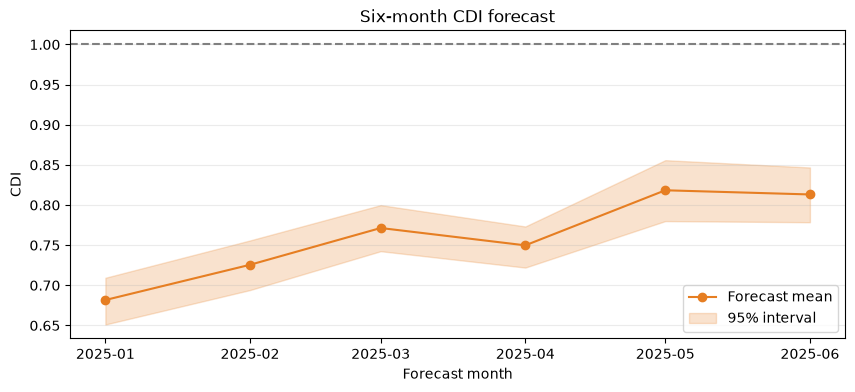

In [9]:
ts = output.charts.get("timeseries", {})
datasets = {d["label"]: d["data"] for d in ts.get("datasets", [])}
dates = pd.to_datetime(ts.get("labels", []))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for label, color in [("PDI", "#2980B9"), ("TDI", "#E67E22"), ("VDI", "#27AE60")]:
    if label in datasets:
        axes[0].plot(dates, datasets[label], label=label, color=color)
axes[0].axhline(1.0, color="grey", linestyle="--", linewidth=1)
axes[0].set_ylabel("Sub-index")
axes[0].set_title("Drought component indices")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

if "CDI" in datasets:
    axes[1].plot(dates, datasets["CDI"], color="#C0392B", label="CDI")
    axes[1].axhline(0.90, color="#F39C12", linestyle=":", label="Mild drought")
    axes[1].axhline(0.65, color="#E74C3C", linestyle=":", label="Severe threshold")
axes[1].set_ylabel("CDI")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

forecast = output.charts.get("forecast", {})
if forecast.get("dates"):
    future = pd.to_datetime(forecast["dates"])
    mean = np.asarray(forecast["mean"], dtype=float)
    lower = np.asarray(forecast.get("ci_lower", mean), dtype=float)
    upper = np.asarray(forecast.get("ci_upper", mean), dtype=float)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(future, mean, marker="o", color="#E67E22", label="Forecast mean")
    ax.fill_between(future, lower, upper, color="#E67E22", alpha=0.22, label="95% interval")
    ax.axhline(1.0, color="grey", linestyle="--")
    ax.set_ylabel("CDI")
    ax.set_xlabel("Forecast month")
    ax.set_title("Six-month CDI forecast")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.show()


### 7b. Severity distribution and population exposure

UN OCHA's People-in-Need methodology treats "population affected" as the
foundational metric that humanitarian response sizing and funding asks are
built on — the same logic applies to drought response. `severity_distribution`
classifies the most recent CDI raster into severity bands and, alongside the
existing percentage-of-valid-pixels view, performs a best-effort raster
zonal sum of WorldPop population per band:

- `stats['total_population']`: population covered by the most recent CDI
  raster;
- `stats['population_affected']`: population in **Extreme drought + Severe
  drought** zones only (`DROUGHT_AT_RISK_LABELS`);
- `severity_distribution['data_population']`: population per severity class
  actually present in this AOI/date.

Population fetch requires `aoi_geojson` and is best-effort — it is simply
absent if WorldPop could not be fetched.


In [ ]:
severity = output.charts.get("severity_distribution", {})
if severity.get("labels"):
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(severity["labels"], severity["data"], color=severity.get("colors"))
    ax.bar_label(bars, fmt="%.1f%%")
    ax.set_ylabel("Valid pixels (%)")
    ax.set_title("Latest CDI severity distribution")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    plt.show()

total_population = output.stats.get("total_population")
population_affected = output.stats.get("population_affected")

if total_population is not None:
    print(f"Total population under the latest CDI raster: {total_population:,.0f}")
    print(
        f"Population in Extreme/Severe drought zones: {population_affected:,.0f} "
        f"({population_affected / total_population:.1%})"
    )

    pop_data = severity.get("data_population")
    if pop_data:
        fig, ax = plt.subplots(figsize=(9, 4))
        bars = ax.bar(severity["labels"], pop_data, color=severity.get("colors"))
        ax.bar_label(bars, fmt="%.0f")
        ax.set_ylabel("Population")
        ax.set_title("Population exposed by drought-severity class")
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
        plt.show()
else:
    print("Population data was not available for this AOI/date.")


## 8. Locate spatial artifacts

The analysis may produce GeoJSON features and one or more Cloud-Optimized GeoTIFF
files. GeoJSON is convenient for APIs and interactive maps, while COGs preserve
continuous raster coverage for GIS software and cloud-native access.

The following cell reports the artifacts without attempting to display a large
raster inside the notebook.


In [10]:
print("GeoJSON type:", output.geojson.get("type"))
print("GeoJSON features:", len(output.geojson.get("features", [])))
print("Raster path(s):", output.raster_path)

if output.raster_path:
    paths = (
        output.raster_path.values()
        if isinstance(output.raster_path, dict)
        else [output.raster_path]
    )
    for path in paths:
        artifact = Path(path)
        print(f"{artifact.name}: exists={artifact.exists()}")


GeoJSON type: FeatureCollection
GeoJSON features: 72
Raster path(s): {'PDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_PDI.tif', 'TDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_TDI.tif', 'VDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_VDI.tif', 'CDI': '/home/odero-george/workspace/climate-change/outputs/drought_2005_2024_CDI.tif'}
drought_2005_2024_PDI.tif: exists=True
drought_2005_2024_TDI.tif: exists=True
drought_2005_2024_VDI.tif: exists=True
drought_2005_2024_CDI.tif: exists=True


## 9. Optional: generate a PDF report

Setting `GENERATE_REPORT` to `True` reruns the same request and asks the package to
assemble a PDF containing metadata, statistics, charts, interpretation text, and
available map content. Keep it `False` during exploration to avoid an unnecessary
second model run.


In [11]:
GENERATE_REPORT = True

if GENERATE_REPORT:
    report_output = await run_analysis(
        **analysis_args,
        report_output_dir=str(REPORT_DIR),
    )
    print("Report:", report_output.metadata.get("report_path"))

Report: /home/odero-george/workspace/climate-change/reports/drought_20260703_134142.pdf
